In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )



/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23265408/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [2]:
dataorchestrator    = (DataOrchestrator(config).build())
shallowdata         = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(dataorchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23265408/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(



==                   gcn_-_bn                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.1941, val loss: 0.1128 ✓ (new best)
Epoch 11 train loss: 0.1201, val loss: 0.0958 ✓ (new best)
Epoch 21 train loss: 0.1136, val loss: 0.0933 ✓ (new best)
Epoch 31 train loss: 0.1088, val loss: 0.0915 ✓ (new best)
Epoch 41 train loss: 0.1043, val loss: 0.0901 ✓ (new best)
Epoch 51 train loss: 0.1014, val loss: 0.0892 (patience: 2/20)
Epoch 61 train loss: 0.0991, val loss: 0.0886 (patience: 4/20)
Epoch 71 train loss: 0.0970, val loss: 0.0881 (patience: 7/20)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 81 train loss: 0.0949, val loss: 0.0877 ✓ (new best)
Epoch 91 train loss: 0.0947, val loss: 0.0875 (patience: 6/20)
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 618.16it/s]

additonal transformation
Test loss: 0.0815
forecasted ✓



==                   gcn_-_id                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.1557, val loss: 0.0911 ✓ (new best)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 11 train loss: 0.0992, val loss: 0.0888 (patience: 9/20)
lr has been updated from 5.00e-05 to 2.50e-05
Epoch 21 train loss: 0.0980, val loss: 0.0881 (patience: 2/20)
Epoch 31 train loss: 0.0971, val loss: 0.0878 (patience: 3/20)
Epoch 41 train loss: 0.0961, val loss: 0.0875 (patience: 3/20)
Epoch 51 train loss: 0.0957, val loss: 0.0873 (patience: 3/20)
Epoch 61 train loss: 0.0968, val loss: 0.0871 (patience: 3/20)
Epoch 71 train loss: 0.0949, val loss: 0.0870 (patience: 6/20)
Epoch 81 train loss: 0.0945, val loss: 0.0868 (patience: 6/20)
Epoch 91 train loss: 0.0950, val loss: 0.0867 (patience: 1/20)
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 633.24it/s]

additonal transformation
Test loss: 0.0837
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

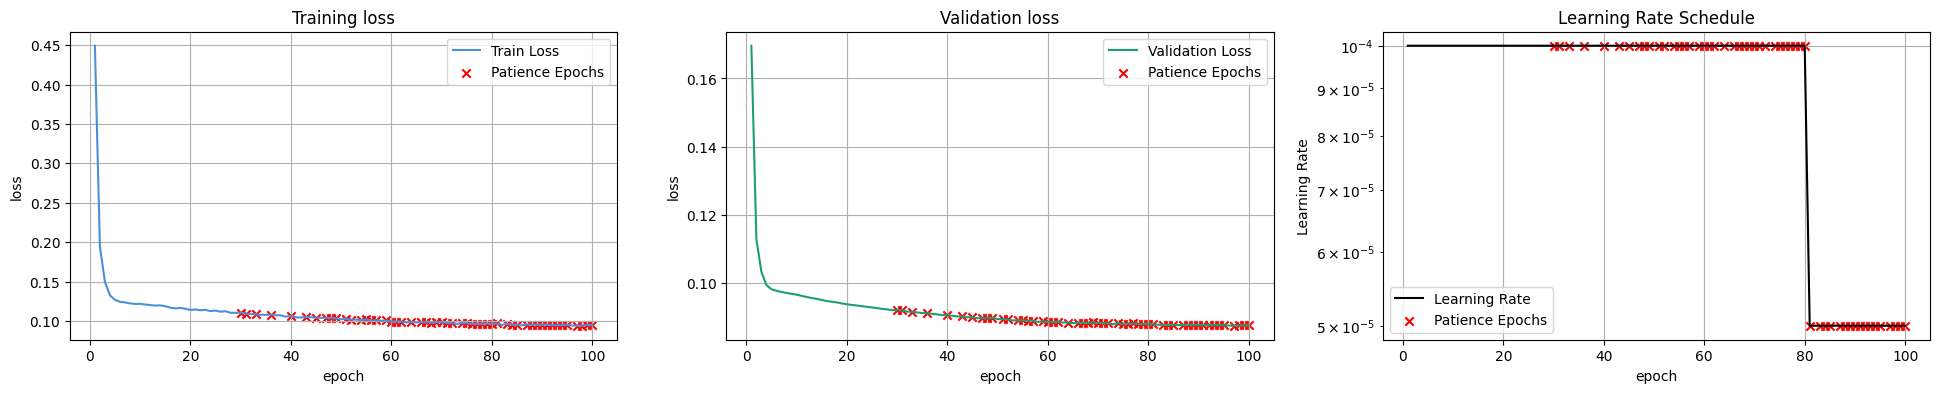

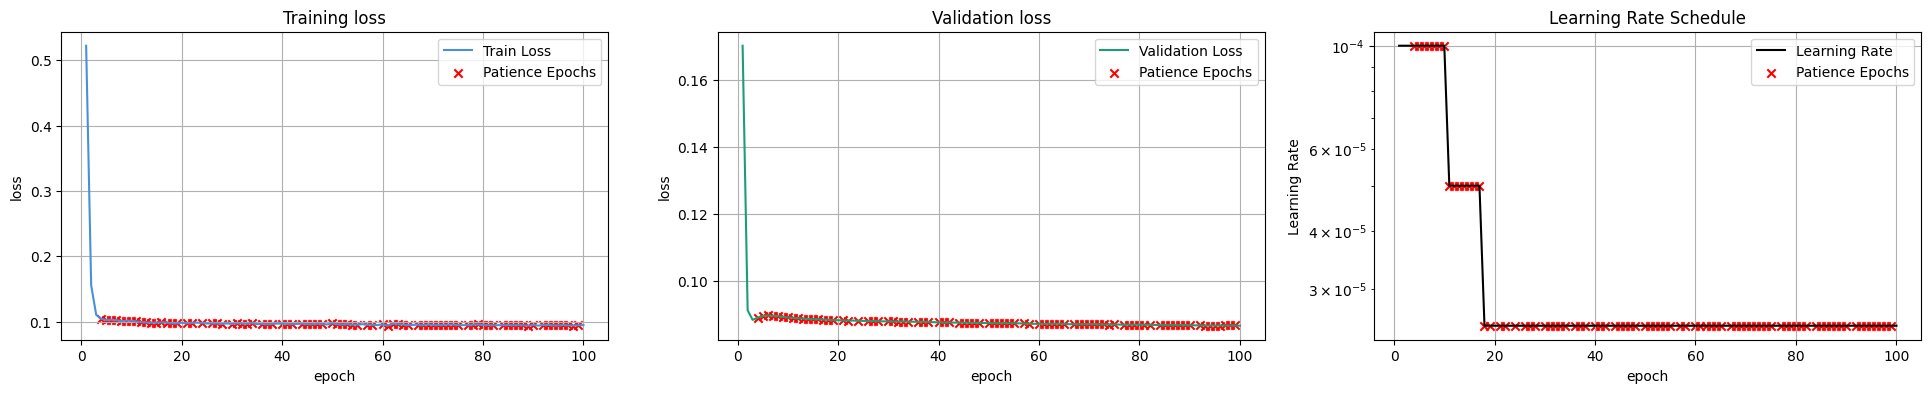

In [3]:
from src.models import SpatialGNNModel

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gcn_bn = SpatialGNNModel(graphdataloader_bn, name = 'gcn - bn',verbose = 2)
gcn_bn.set_model_hparams()
gcn_bn.set_global_hparams(**global_hparams)
gcn_bn.train()
gcn_bn.forecast('test')
gcn_bn.show_forecasts(26)

gcn_id = SpatialGNNModel(graphdataloader_id, name = 'gcn - id',verbose = 2)
gcn_id.set_model_hparams()
gcn_id.set_global_hparams(**global_hparams)
gcn_id.train()
gcn_id.forecast('test')
gcn_id.show_forecasts(26)

In [4]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

climateology = ClimateologyModel(shallowdata)
climateology.forecast('test')




ClimateologyModel(name='climateology_model')

computing metrics:   0%|                                                                                                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.64it/s]


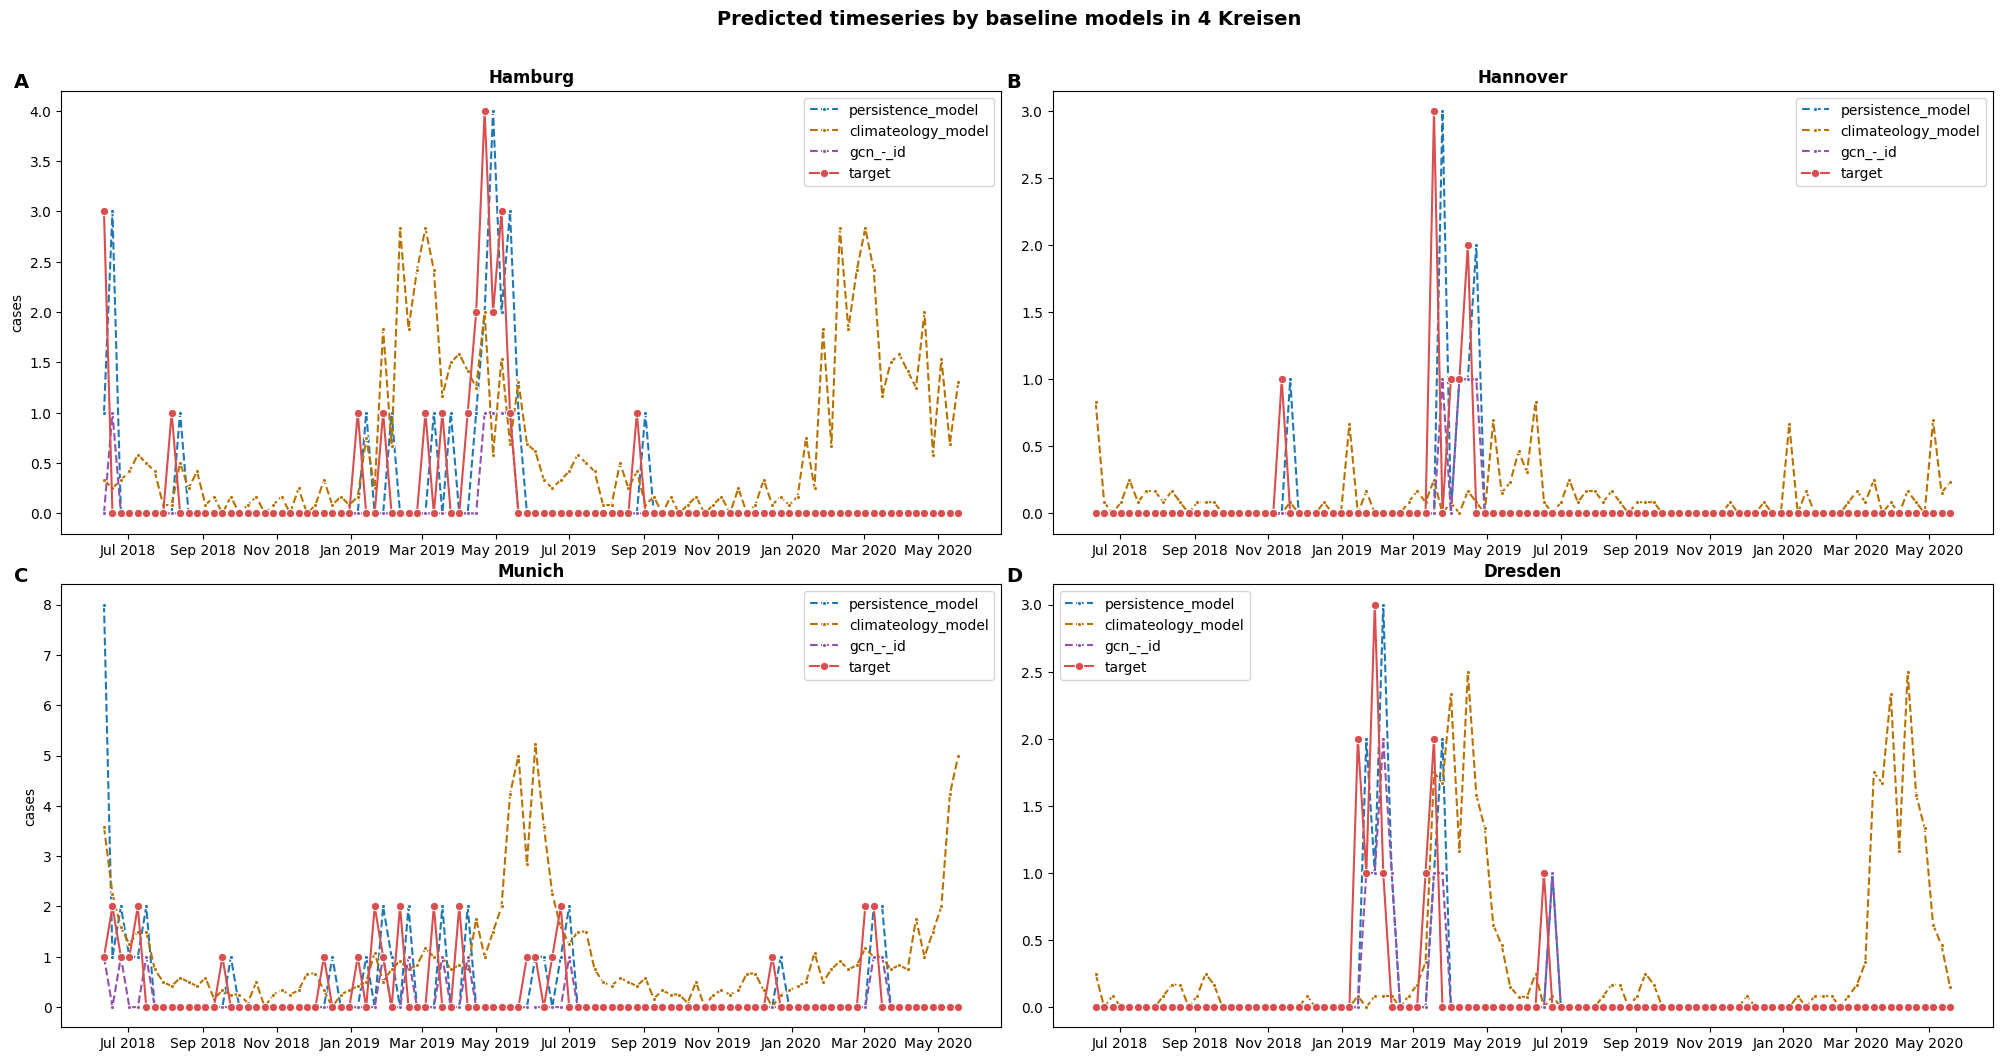

In [5]:
from src.evaluation import Evaluator

evaluation = Evaluator([persistence,climateology,gcn_id]).add_evaluation()


predicted_timeseries_raw = evaluation.plotter.plot_timeseries([15,26,223,356], 0)



predicted_timeseries = (predicted_timeseries_raw
        .labels.change_suptitle('Predicted timeseries by baseline models in 4 Kreisen', fontweight = 'bold', fontsize = 14)         
        .labels.set_suptitle_y(y=1.05)
        .labels.change_title(title = 'Hamburg',  ax = 0, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Hannover', ax = 1, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Munich',   ax = 2, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Dresden',  ax = 3, fontsize = 12, fontweight = 'bold')   
        .labels.change_ylab('cases', ax = 0)
        .labels.change_ylab('cases', ax = 2)
        .labels.set_tag('A', y = 1.04, ax = 0)
        .labels.set_tag('B', y = 1.04, ax = 1)
        .labels.set_tag('C', y = 1.04, ax = 2)
        .labels.set_tag('D', y = 1.04, ax = 3)                        
        .change_figsize(20,10)         
        .layout.grid('off')
        )
predicted_timeseries.show()

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.68it/s]


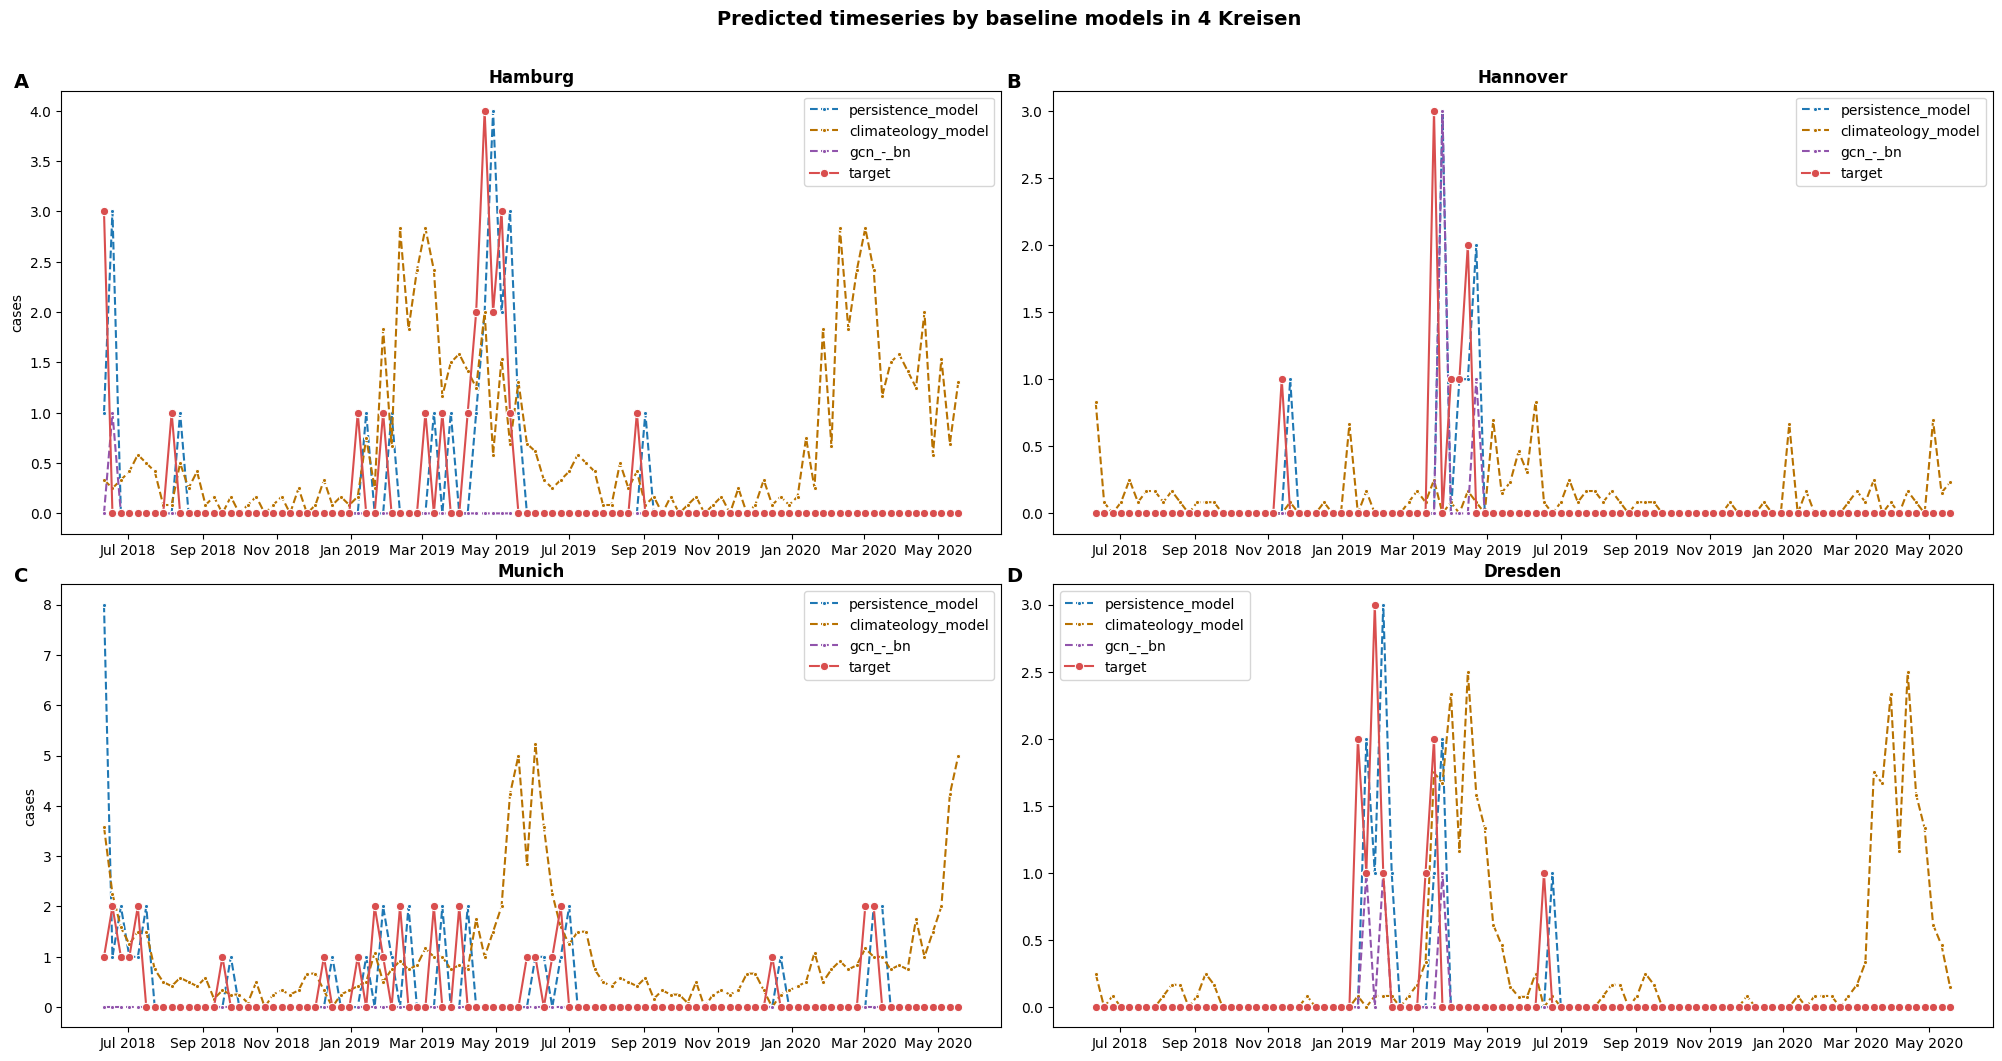

In [6]:
from src.evaluation import Evaluator

evaluation = Evaluator([persistence,climateology,gcn_bn]).add_evaluation()


predicted_timeseries_raw = evaluation.plotter.plot_timeseries([15,26,223,356], 0)



predicted_timeseries = (predicted_timeseries_raw
        .labels.change_suptitle('Predicted timeseries by baseline models in 4 Kreisen', fontweight = 'bold', fontsize = 14)         
        .labels.set_suptitle_y(y=1.05)
        .labels.change_title(title = 'Hamburg',  ax = 0, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Hannover', ax = 1, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Munich',   ax = 2, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Dresden',  ax = 3, fontsize = 12, fontweight = 'bold')   
        .labels.change_ylab('cases', ax = 0)
        .labels.change_ylab('cases', ax = 2)
        .labels.set_tag('A', y = 1.04, ax = 0)
        .labels.set_tag('B', y = 1.04, ax = 1)
        .labels.set_tag('C', y = 1.04, ax = 2)
        .labels.set_tag('D', y = 1.04, ax = 3)                        
        .change_figsize(20,10)         
        .layout.grid('off')
        )
predicted_timeseries.show()

computing metrics:   0%|                                                                                                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:03<00:00,  1.84it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

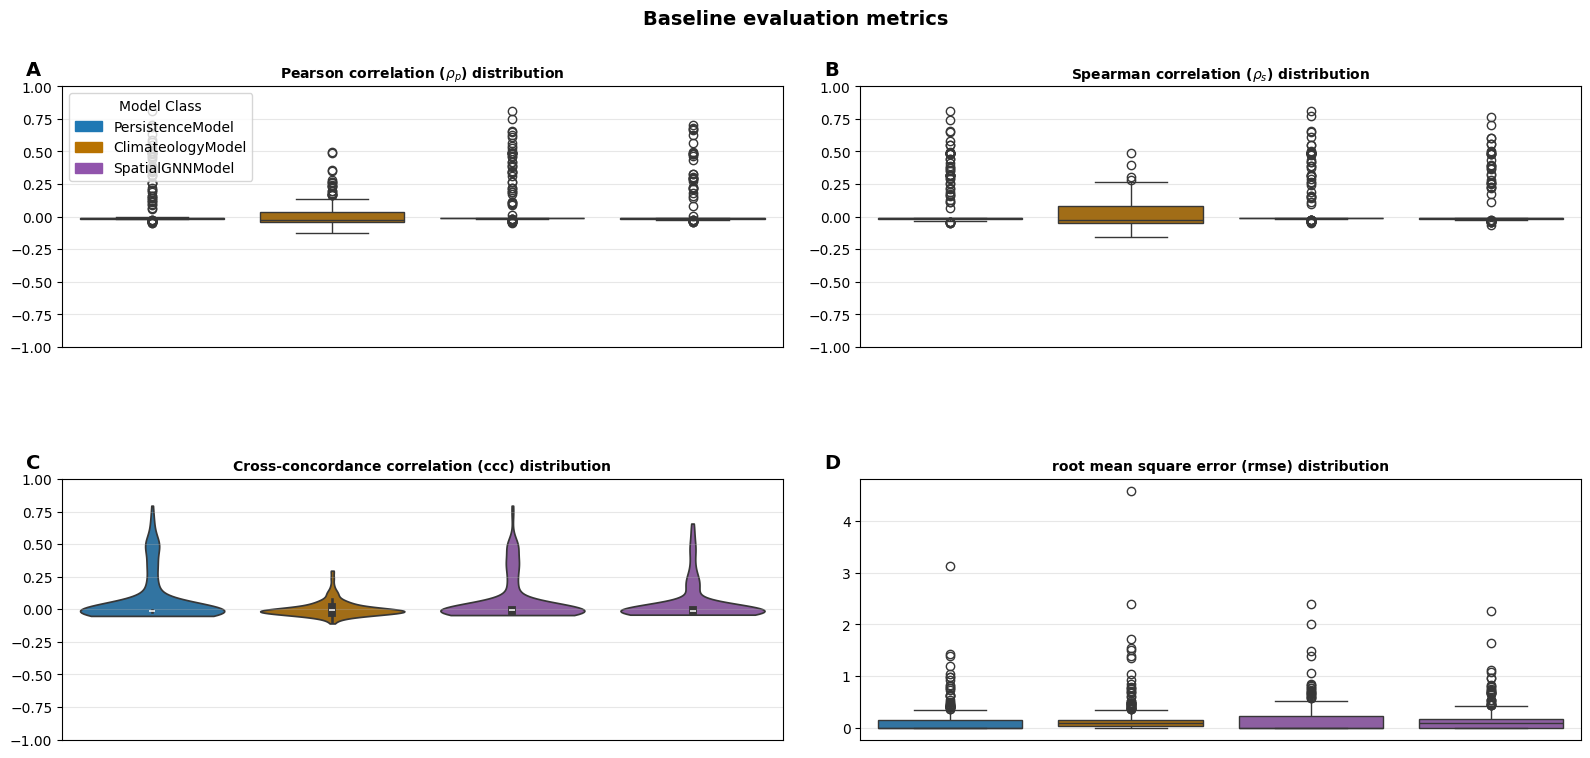

In [7]:
full_eval = Evaluator([persistence,climateology,gcn_id,gcn_bn]).add_evaluation()
f_merged_raw    = full_eval.plotter.plot_metric_compilation(subfig_size = (8,4));

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Baseline evaluation metrics', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([])
    .layout.set_ylim([-1,1],ax = 0)
    .layout.set_ylim([-1,1],ax = 1)
    .layout.set_ylim([-1,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)             
    )
f_merged.show()


==                   gcn - bn                   ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.4788, val loss: 0.3423 ✓ (new best)
Epoch 2 train loss: 0.4022, val loss: 0.3227 ✓ (new best)
Epoch 3 train loss: 0.3474, val loss: 0.3122 ✓ (new best)
Epoch 4 train loss: 0.3239, val loss: 0.3085 ✓ (new best)
Epoch 5 train loss: 0.3138, val loss: 0.3074 ✓ (new best)
Epoch 6 train loss: 0.3155, val loss: 0.3068 ✓ (new best)
Epoch 7 train loss: 0.3089, val loss: 0.3058 ✓ (new best)
Epoch 8 train loss: 0.3019, val loss: 0.3051 ✓ (new best)
Epoch 9 train loss: 0.3032, val loss: 0.3044 ✓ (new best)
Epoch 10 train loss: 0.3016, val loss: 0.3036 ✓ (new best)
Epoch 11 train loss: 0.3013, val loss: 0.3031 ✓ (new best)
Epoch 12 train loss: 0.2984, val loss: 0.3025 ✓ (new best)
Epoch 13 train loss: 0.2980, val loss: 0.3019 ✓ (new best)
Epoch 14 train loss: 0.2965, val loss: 0.3013 ✓ (new best)
Epoch 15 train loss: 0.2945, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 587.67it/s]


Test loss: 0.2656
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

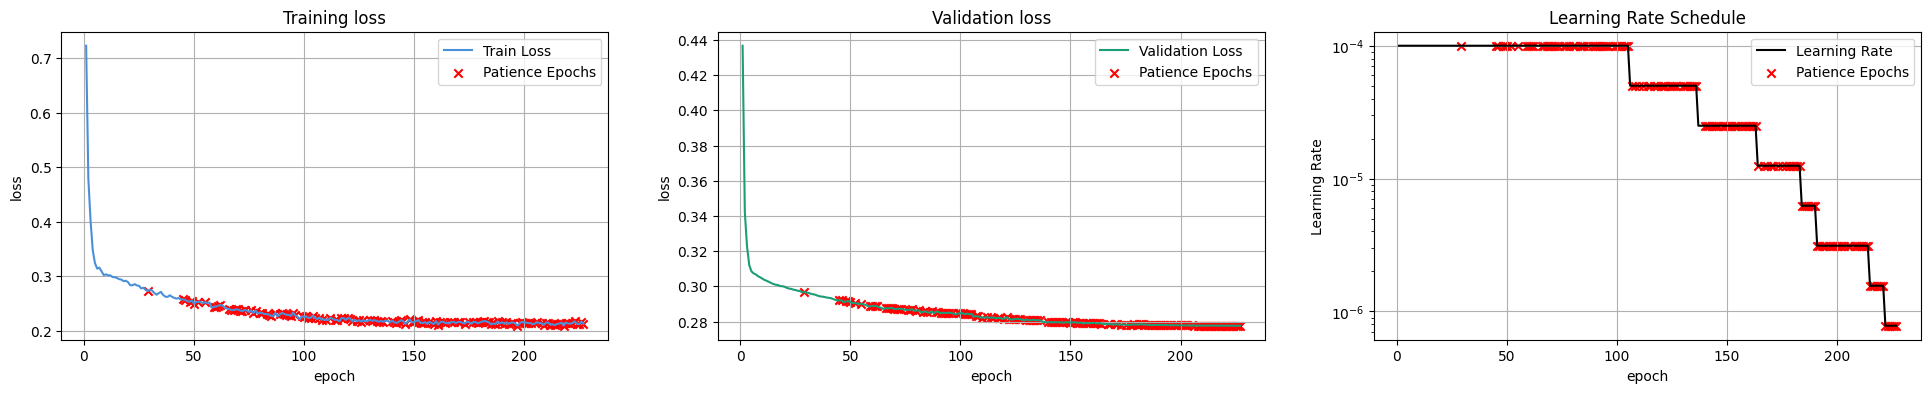

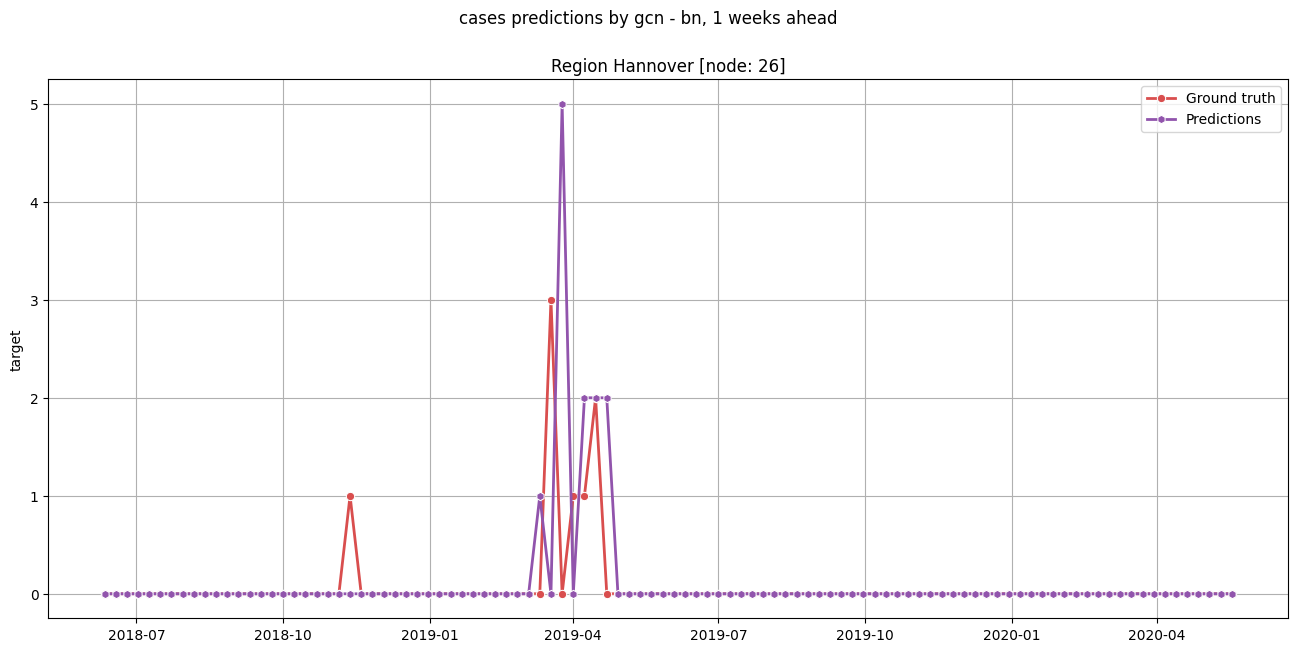

In [8]:
from src.models import SpatialGNNModel

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'outbreakpoisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gcn = SpatialGNNModel(graphdataloader_bn, name = 'gcn - bn')
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train(verbose = 2)
gcn.forecast('test')
gcn.show_forecasts(26)

(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'SK Hamburg [node: 15]'}, ylabel='target'>])

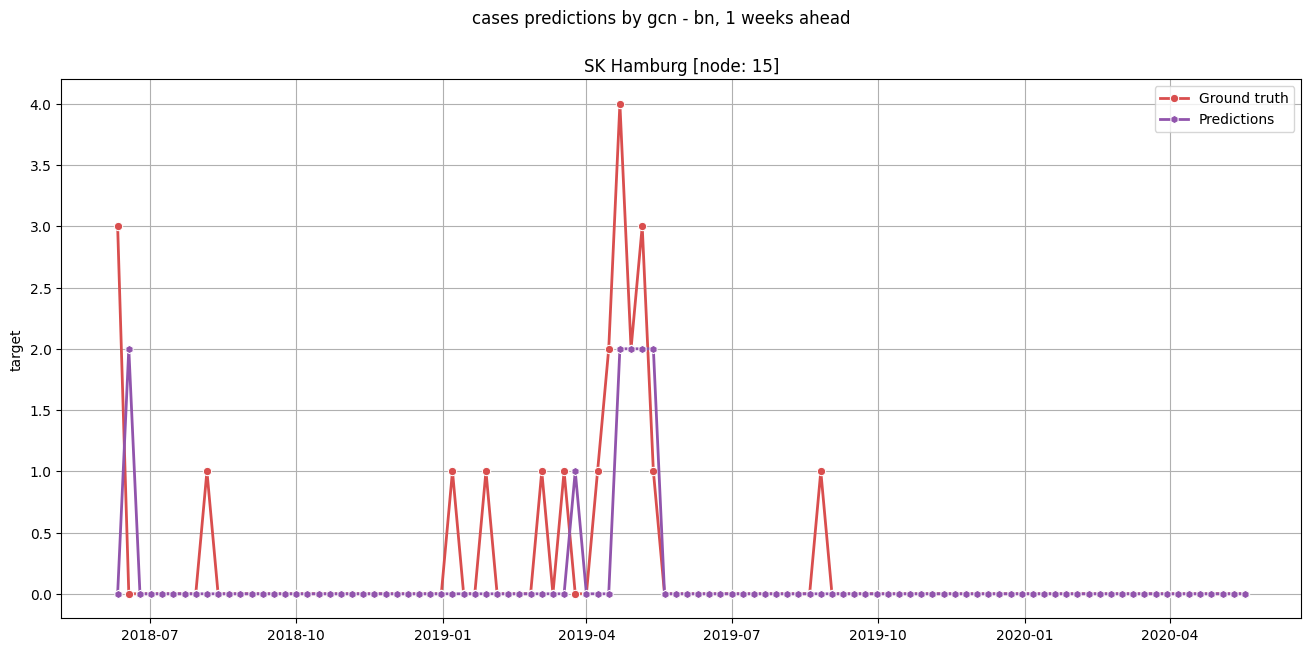

In [9]:
gcn.show_forecasts(15)